## EXERCISE 4 - TEXT PREPROCESSING



*   nadhila alya azzahra (051)
*   gloria jesika oktoniar pardosi (148)



**WEB SCRAPING**

source : https://play.google.com/storeapps/details?id=com.telkomsel.telkomselcm&hl=id


In [ ]:
!pip install -q google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import time
from google_play_scraper import app, reviews, Sort

In [ ]:
app_id = 'com.telkomsel.telkomselcm'  #ID apk MyTelkomsel
bahasa = 'id'
negara = 'id'
jumlah_halaman = 10   # brp halaman yg diambil
review_per_halaman = 200  # 1 halaman = 200 review

In [ ]:
# ngecek apakah app_id benar
info = app(app_id, lang=bahasa, country=negara)
print("Nama aplikasi:", info['title'])
print("Rating:", info['score'])

Nama aplikasi: MyTelkomsel – Beli Pulsa/Kuota
Rating: 4.4196773


In [ ]:
nomor_halaman = []
nama_user = []
rating = []
tanggal = []
isi_teks = []

In [ ]:
token = None   # token awal kosong = mulai dari halaman pertama
for halaman in range(1, jumlah_halaman + 1):
  hasil, token = reviews(
      app_id,
      lang=bahasa,
      country=negara,
      sort=Sort.NEWEST,
      count=review_per_halaman,
      continuation_token=token      # lanjut dari halaman sebelumnya
  )

  # append tiap review ke array
  for r in hasil:
    nomor_halaman.append(halaman)
    nama_user.append(r['userName'])
    rating.append(r['score'])
    tanggal.append(r['at'])
    isi_teks.append(r['content'])
  print(f"Selesai scrape halaman ke-{halaman}, total review: {len(isi_teks)}")

  # berhenti kalau sudah tidak ada halaman berikutnya
  if token is None:
    print("Review sudah habis.")
    break
  time.sleep(1)   # jeda 1 detik supaya tidak terlalu cepat

Selesai scrape halaman ke-1, total review: 200
Selesai scrape halaman ke-2, total review: 400
Selesai scrape halaman ke-3, total review: 600
Selesai scrape halaman ke-4, total review: 800
Selesai scrape halaman ke-5, total review: 1000
Selesai scrape halaman ke-6, total review: 1200
Selesai scrape halaman ke-7, total review: 1400
Selesai scrape halaman ke-8, total review: 1600
Selesai scrape halaman ke-9, total review: 1800
Selesai scrape halaman ke-10, total review: 2000


In [ ]:
len(nomor_halaman), len(nama_user), len(rating), len(tanggal), len(isi_teks)

(2000, 2000, 2000, 2000, 2000)

In [ ]:
df_multipage = pd.DataFrame({
    'Halaman': nomor_halaman,
    'Nama_User': nama_user,
    'Rating': rating,
    'Tanggal': tanggal,
    'Ringkasan_Heading': isi_teks
})
df_multipage

,Halaman,Nama_User,Rating,Tanggal,Ringkasan_Heading
0,1,Nofita Sari,4,2026-10-03 14:09:22,lumayan bagus praktis beli paket dat dan pulsa
1,1,Muhammad Irfan,1,2026-10-03 14:04:51,Kualitas Jaringan Sangat Buruk Harga Paket Den...
2,1,Hery Susanto,1,2026-10-03 14:00:05,tai aplilasi kaya tai
3,1,Dhani Jambi80,1,2026-10-03 13:57:44,Telkomsel sinyal lemah kuota mahal... mengecew...
4,1,Hasan Asy'ari,1,2026-10-03 13:53:36,susah banget sekarang dapetin sms link verifik...
...,...,...,...,...,...
1995,10,David Fawwaz Nugraha,1,2026-09-26 12:14:08,Jaringan area saya udah 5 tahun masih tetap bu...
1996,10,AL Qaish,1,2026-09-26 12:11:51,"KENAPA KUOTA TIDAK DI JUAL UTUH, CONTOHNYA SER..."
1997,10,Aji Santoso,5,2026-09-26 12:00:40,sangat bagus
1998,10,Hari Poe,2,2026-09-26 11:55:09,"kurang memuaskan skrng,stiap pengisian pulsa s..."


In [ ]:
print("Jumlah data (baris, kolom):", df_multipage.shape)
print("Nama kolom:", df_multipage.columns.tolist())
print("Data kosong di Ringkasan_Heading:", df_multipage['Ringkasan_Heading'].isnull().sum())
df_multipage['Halaman'].value_counts().sort_index()

Jumlah data (baris, kolom): (2000, 5)
Nama kolom: ['Halaman', 'Nama_User', 'Rating', 'Tanggal', 'Ringkasan_Heading']
Data kosong di Ringkasan_Heading: 0


,count
Halaman,
1,200
2,200
3,200
4,200
5,200
6,200
7,200
8,200
9,200


In [ ]:
# Data mentah hasil scraping
df_mentah = df_multipage[
    ["Halaman", "Nama_User", "Rating", "Tanggal", "Ringkasan_Heading"]
]
df_mentah.to_csv(
    "review_mytelkomsel_mentah.csv",
    index=False,
    encoding="utf-8-sig"
)

**TEXT PREPROCESSING**

tahap preprocessing bertujuan membersihkan data hasil scraping agar lebih siap digunakan pada proses analisis teks

In [ ]:
!pip install Sastrawi # library utk bhs indonesia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.2 MB/s eta 0:00:00


In [ ]:
import re   # utk pola teks (regex)
import string   # daftar tanda baca
import unicodedata  # utk menormalkan huruf
from collections import Counter   #counter utk menghitung frekuensi kata
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [ ]:
# pastikan semua isi bertipe teks (kalau ada yang kosong jadi string kosong)
df_multipage['Ringkasan_Heading'] = df_multipage['Ringkasan_Heading'].fillna('').astype(str)

df_multipage[['Ringkasan_Heading']].head(10)

,Ringkasan_Heading
0,lumayan bagus praktis beli paket dat dan pulsa
1,Kualitas Jaringan Sangat Buruk Harga Paket Den...
2,tai aplilasi kaya tai
3,Telkomsel sinyal lemah kuota mahal... mengecew...
4,susah banget sekarang dapetin sms link verifik...
5,njir aplikasi gak jelas ngebug terus keluar ma...
6,👍🏻👍🏻👍🏻
7,terlalu lambat responya
8,saya melihat nya
9,mantap


1. remove HTML Tags

menghapus tag HTML yang mungkin masih muncul pada hasil scraping sehingga hanya menyisakan isi teks

In [ ]:
def hapus_html(teks):
    return re.sub(r'<.*?>', ' ', teks)

df_multipage['1_html'] = df_multipage['Ringkasan_Heading'].apply(hapus_html)
df_multipage[['Ringkasan_Heading', '1_html']].head(5)

,Ringkasan_Heading,1_html
0,lumayan bagus praktis beli paket dat dan pulsa,lumayan bagus praktis beli paket dat dan pulsa
1,Kualitas Jaringan Sangat Buruk Harga Paket Den...,Kualitas Jaringan Sangat Buruk Harga Paket Den...
2,tai aplilasi kaya tai,tai aplilasi kaya tai
3,Telkomsel sinyal lemah kuota mahal... mengecew...,Telkomsel sinyal lemah kuota mahal... mengecew...
4,susah banget sekarang dapetin sms link verifik...,susah banget sekarang dapetin sms link verifik...


2. remove hashtag

menghapus simbol hashtag (#) dengan begitu menghasilkan teks yang lebih bersih dan mudah di proses pada tahap berikutnya

In [ ]:
def hapus_hashtag(teks):
    return re.sub(r'#\w+', ' ', teks)

df_multipage['2_hashtag'] = df_multipage['1_html'].apply(hapus_hashtag)
df_multipage[['1_html', '2_hashtag']].head(5)

,1_html,2_hashtag
0,lumayan bagus praktis beli paket dat dan pulsa,lumayan bagus praktis beli paket dat dan pulsa
1,Kualitas Jaringan Sangat Buruk Harga Paket Den...,Kualitas Jaringan Sangat Buruk Harga Paket Den...
2,tai aplilasi kaya tai,tai aplilasi kaya tai
3,Telkomsel sinyal lemah kuota mahal... mengecew...,Telkomsel sinyal lemah kuota mahal... mengecew...
4,susah banget sekarang dapetin sms link verifik...,susah banget sekarang dapetin sms link verifik...


3. lower casing

mengubah seluruh huruf menjadi huruf kecil agar kata dengan penulisan berbeda dianggap sama

In [ ]:
def huruf_kecil(teks):
    teks = unicodedata.normalize('NFKC', teks)   # ubah huruf berfont unik jadi huruf biasa
    return teks.lower()

df_multipage['3_lower'] = df_multipage['2_hashtag'].apply(huruf_kecil)
df_multipage[['2_hashtag', '3_lower']].head(5)

,2_hashtag,3_lower
0,lumayan bagus praktis beli paket dat dan pulsa,lumayan bagus praktis beli paket dat dan pulsa
1,Kualitas Jaringan Sangat Buruk Harga Paket Den...,kualitas jaringan sangat buruk harga paket den...
2,tai aplilasi kaya tai,tai aplilasi kaya tai
3,Telkomsel sinyal lemah kuota mahal... mengecew...,telkomsel sinyal lemah kuota mahal... mengecew...
4,susah banget sekarang dapetin sms link verifik...,susah banget sekarang dapetin sms link verifik...


4. remove URL, HTTP, and E-mail

karena informasi dari tautan website atau alamat email tidak memberi makna yang signifikan maka perlu dihapus

In [ ]:
def hapus_url_email(teks):
    teks = re.sub(r'http\S+|www\.\S+', ' ', teks)   # hapus URL / http
    teks = re.sub(r'\S+@\S+', ' ', teks)            # hapus e-mail
    return teks

df_multipage['4_url_email'] = df_multipage['3_lower'].apply(hapus_url_email)
df_multipage[['3_lower', '4_url_email']].head(5)

,3_lower,4_url_email
0,lumayan bagus praktis beli paket dat dan pulsa,lumayan bagus praktis beli paket dat dan pulsa
1,kualitas jaringan sangat buruk harga paket den...,kualitas jaringan sangat buruk harga paket den...
2,tai aplilasi kaya tai,tai aplilasi kaya tai
3,telkomsel sinyal lemah kuota mahal... mengecew...,telkomsel sinyal lemah kuota mahal... mengecew...
4,susah banget sekarang dapetin sms link verifik...,susah banget sekarang dapetin sms link verifik...


In [ ]:
#contoh yg berubah
df_multipage[df_multipage['3_lower'] != df_multipage['4_url_email']][['3_lower', '4_url_email']].head(5)

,3_lower,4_url_email
1600,di kota sinyal nya busuk banget kadang ada kad...,di kota sinyal nya busuk banget kadang ada kad...


5. remove punctuations

menghapus seluruh tanda baca dengan demikian teks hanya berisi kata-kata

In [ ]:
def hapus_tanda_baca(teks):
    teks = teks.translate(str.maketrans('', '', string.punctuation))
    teks = re.sub(r'\s+', ' ', teks).strip()   # rapikan spasi berlebih
    return teks

df_multipage['5_punct'] = df_multipage['4_url_email'].apply(hapus_tanda_baca)
df_multipage[['4_url_email', '5_punct']].head(5)

,4_url_email,5_punct
0,lumayan bagus praktis beli paket dat dan pulsa,lumayan bagus praktis beli paket dat dan pulsa
1,kualitas jaringan sangat buruk harga paket den...,kualitas jaringan sangat buruk harga paket den...
2,tai aplilasi kaya tai,tai aplilasi kaya tai
3,telkomsel sinyal lemah kuota mahal... mengecew...,telkomsel sinyal lemah kuota mahal mengecewakan
4,susah banget sekarang dapetin sms link verifik...,susah banget sekarang dapetin sms link verifik...


6. removal of emojis

menghapus emoji ataupun simbol unicode yang terdapat di review pengguna supaya data menjadi lebih bersih

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 14.9 MB/s eta 0:00:00


In [ ]:
import emoji
def hapus_emoji(teks):
    teks = emoji.replace_emoji(teks, replace=' ')    # hapus semua emoji
    teks = re.sub(r'[\u200d\ufe0f]', ' ', teks)      # sisa karakter penyambung emoji
    teks = re.sub(r'\s+', ' ', teks).strip()         # rapikan spasi
    return teks

df_multipage['6_emoji'] = df_multipage['5_punct'].apply(hapus_emoji)
df_multipage[df_multipage['5_punct'] != df_multipage['6_emoji']][['5_punct', '6_emoji']].head(10)

,5_punct,6_emoji
6,👍🏻👍🏻👍🏻,
21,aplikasi lemot mau isi kuota malah masuk ke no...,aplikasi lemot mau isi kuota malah masuk ke no...
24,😊 bintang membuktikan bahwa,bintang membuktikan bahwa
48,telkomsel juga makin parah banget jaringannya ...,telkomsel juga makin parah banget jaringannya ...
54,makin rusak apk susah d buka 🤯🤯🤯,makin rusak apk susah d buka
61,selamat malam saya ingin menyampaikan keluhan ...,selamat malam saya ingin menyampaikan keluhan ...
75,💥,
87,👍👍👍,
92,aku sampe bingung mau kasi bintang berapa😭😭 ke...,aku sampe bingung mau kasi bintang berapa kena...
93,8 tahun pakai telkomsel 2x mengalami hal stam ...,8 tahun pakai telkomsel 2x mengalami hal stam ...


7. remove stopwords

menghapus kata-kata umum seperti yang, dan, di yang tidak memberikan informasi penting

In [ ]:
stopwords_id = set(StopWordRemoverFactory().get_stop_words())

def hapus_stopword(teks):
    kata = teks.split()
    kata = [k for k in kata if k not in stopwords_id]
    return ' '.join(kata)

df_multipage['7_stopword'] = df_multipage['6_emoji'].apply(hapus_stopword)
df_multipage[['6_emoji', '7_stopword']].head(5)

,6_emoji,7_stopword
0,lumayan bagus praktis beli paket dat dan pulsa,lumayan bagus praktis beli paket dat pulsa
1,kualitas jaringan sangat buruk harga paket den...,kualitas jaringan sangat buruk harga paket kua...
2,tai aplilasi kaya tai,tai aplilasi kaya tai
3,telkomsel sinyal lemah kuota mahal mengecewakan,telkomsel sinyal lemah kuota mahal mengecewakan
4,susah banget sekarang dapetin sms link verifik...,susah banget sekarang dapetin sms link verifik...


8. remove frequent words

menghapus kata-kata yang muncul terlalu sering pada seluruh dataset karena yang dominan terkadang tidak memberikan informasi yang spesifik

In [ ]:
# hitung frekuensi semua kata
semua_kata = ' '.join(df_multipage['7_stopword']).split()
frekuensi = Counter(semua_kata)

print("10 kata paling sering muncul:")
print(frekuensi.most_common(10))

10 kata paling sering muncul:
[('mahal', 505), ('paket', 456), ('jaringan', 442), ('makin', 399), ('telkomsel', 382), ('nya', 378), ('kuota', 314), ('aplikasi', 291), ('beli', 283), ('sinyal', 283)]


In [ ]:
jumlah_frequent = 10
kata_frequent = set([kata for kata, jumlah in frekuensi.most_common(jumlah_frequent)])

def hapus_frequent(teks):
    return ' '.join([k for k in teks.split() if k not in kata_frequent])

df_multipage['8_frequent'] = df_multipage['7_stopword'].apply(hapus_frequent)
df_multipage[['7_stopword', '8_frequent']].head(5)

,7_stopword,8_frequent
0,lumayan bagus praktis beli paket dat pulsa,lumayan bagus praktis dat pulsa
1,kualitas jaringan sangat buruk harga paket kua...,kualitas sangat buruk harga kualitas sangat ti...
2,tai aplilasi kaya tai,tai aplilasi kaya tai
3,telkomsel sinyal lemah kuota mahal mengecewakan,lemah mengecewakan
4,susah banget sekarang dapetin sms link verifik...,susah banget sekarang dapetin sms link verifik...


9. remove rare words

menghapus kata-kata yang sangat jarang muncul pada dataset karena umumnya tidak memberikan pengaruh yang signifikan terhadap hasil analisis dan dapat menambah kompleksitas data

In [ ]:
frekuensi_baru = Counter(' '.join(df_multipage['8_frequent']).split())

batas_rare = 1   # kata yang muncul <= 1 kali dianggap langka
kata_rare = set([kata for kata, jumlah in frekuensi_baru.items() if jumlah <= batas_rare])
print("Jumlah kata langka:", len(kata_rare))

def hapus_rare(teks):
    return ' '.join([k for k in teks.split() if k not in kata_rare])

df_multipage['9_rare'] = df_multipage['8_frequent'].apply(hapus_rare)
df_multipage[['8_frequent', '9_rare']].head(5)

Jumlah kata langka: 2590


,8_frequent,9_rare
0,lumayan bagus praktis dat pulsa,lumayan bagus praktis dat pulsa
1,kualitas sangat buruk harga kualitas sangat ti...,kualitas sangat buruk harga kualitas sangat ha...
2,tai aplilasi kaya tai,tai kaya tai
3,lemah mengecewakan,lemah mengecewakan
4,susah banget sekarang dapetin sms link verifik...,susah banget sekarang sms verifikasi selalu error


10. stemmer

mengubah kata menjadi bentuk dasarnya, bertujuan menyamakan bentuk kata sehingga proses analisis menjadi lebih efektif

In [ ]:
stemmer = StemmerFactory().create_stemmer()

# agar cepat, stem tiap kata unik sekali saja lalu simpan di kamus
kata_unik = set(' '.join(df_multipage['9_rare']).split())
kamus_stem = {kata: stemmer.stem(kata) for kata in kata_unik}

def stemming(teks):
    return ' '.join([kamus_stem[k] for k in teks.split()])

df_multipage['10_stemmed'] = df_multipage['9_rare'].apply(stemming)
df_multipage[['9_rare', '10_stemmed']].head(5)

,9_rare,10_stemmed
0,lumayan bagus praktis dat pulsa,lumayan bagus praktis dat pulsa
1,kualitas sangat buruk harga kualitas sangat ha...,kualitas sangat buruk harga kualitas sangat ha...
2,tai kaya tai,tai kaya tai
3,lemah mengecewakan,lemah kecewa
4,susah banget sekarang sms verifikasi selalu error,susah banget sekarang sms verifikasi selalu error


In [ ]:
df_multipage['Teks_Bersih'] = df_multipage['10_stemmed']

# perbandingan sebelum dan sesudah
df_multipage[['Ringkasan_Heading', 'Teks_Bersih']].head(15)

,Ringkasan_Heading,Teks_Bersih
0,lumayan bagus praktis beli paket dat dan pulsa,lumayan bagus praktis dat pulsa
1,Kualitas Jaringan Sangat Buruk Harga Paket Den...,kualitas sangat buruk harga kualitas sangat ha...
2,tai aplilasi kaya tai,tai kaya tai
3,Telkomsel sinyal lemah kuota mahal... mengecew...,lemah kecewa
4,susah banget sekarang dapetin sms link verifik...,susah banget sekarang sms verifikasi selalu error
5,njir aplikasi gak jelas ngebug terus keluar ma...,njir gak jelas ngebug terus keluar masuk makan...
6,👍🏻👍🏻👍🏻,
7,terlalu lambat responya,terlalu lambat
8,saya melihat nya,
9,mantap,mantap


In [ ]:
!pip install wordcloud

Word Cloud sebelum preprocessing digunakan untuk melihat kata-kata yang paling sering muncul pada data asli hasil scraping sebelum dilakukan proses pembersihan teks

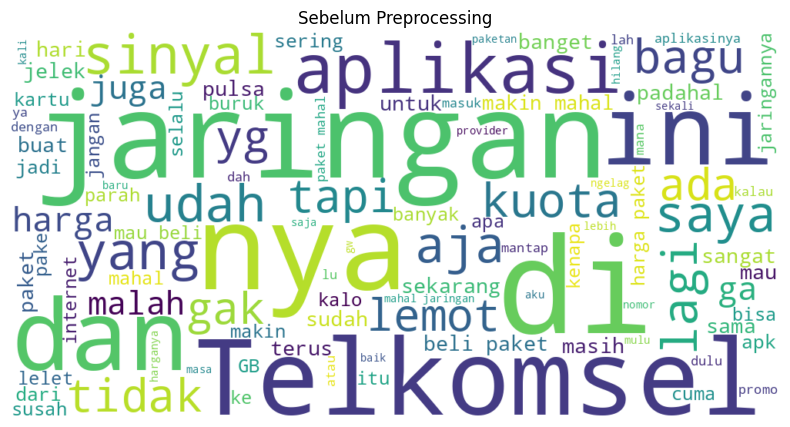

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# gabungkan semua review asli jadi satu teks panjang
text_sebelum = ' '.join(df_multipage['Ringkasan_Heading'].dropna().astype(str))

wordcloud_sebelum = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(text_sebelum)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_sebelum, interpolation='bilinear')
plt.axis('off')
plt.title('Sebelum Preprocessing')
plt.show()

Word Cloud setelah preprocessing digunakan untuk melihat kata-kata yang paling dominan setelah data dibersihkan

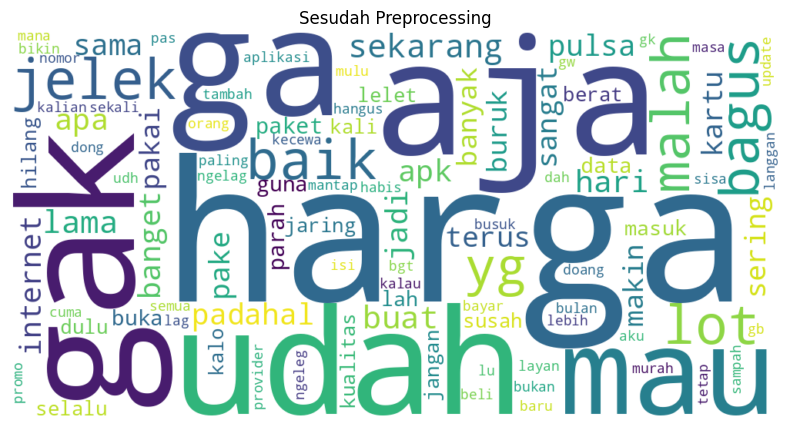

In [ ]:
# gabungkan semua teks yang sudah bersih
text_sesudah = ' '.join(df_multipage['Teks_Bersih'].dropna().astype(str))

wordcloud_sesudah = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(text_sesudah)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_sesudah, interpolation='bilinear')
plt.axis('off')
plt.title('Sesudah Preprocessing')
plt.show()

ngecekk apakah benar-benar berubah

In [ ]:
# berapa review yang isinya berubah setelah preprocessing
berubah = (df_multipage['Ringkasan_Heading'] != df_multipage['Teks_Bersih']).sum()
print("Review yang berubah:", berubah, "dari", len(df_multipage))

# lihat contoh
df_multipage[['Ringkasan_Heading', 'Teks_Bersih']].sample(10)

Review yang berubah: 1745 dari 2000


,Ringkasan_Heading,Teks_Bersih
337,"Dulu Paket Seru 25K dapat 12 GB untuk 7 hari, ...",dulu seru 25k 12 gb 7 hari sekarang kok hilang...
1196,"vero asisten AI, dan Admin tidak membantu meny...",ai admin bantu selesai masalah seperti langkah...
948,"lucu ya telkomsel , udh di persulit mau migras...",lucu udh sulit mau migrasi halo trus gilir udh...
1106,makin lama makin mahal.. kartu dah dipakai leb...,lama kartu dah pakai lebih bukan murah malah a...
485,Telkomsel sekarnang lambat parah,lambat parah
157,tolong kuotanya dipermurah lagi masa iya 100 r...,kuota masa iya 100 rb gb doang kmrn buka gb 10...
1269,oke,oke
376,"ketika saya mau membeli kuota, aplikasi nya cu...",mau beli cuma muter doang padahal bagus sangat...
69,tdk berguna,tdk guna
64,kasih la pket murah bos,kasih la pket murah bos


save jadi CSV

In [ ]:
# Data bersih hasil preprocessing
df_bersih = df_multipage[
    ["Halaman", "Nama_User", "Rating", "Tanggal", "Teks_Bersih"]
]
df_bersih.to_csv(
    "review_mytelkomsel_bersih.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
from google.colab import files
files.download('review_mytelkomsel_mentah.csv')
files.download('review_mytelkomsel_bersih.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**kesimpulan**

berdasarkan hasil preprocessing, review aplikasi MyTelkomsel berhasil dibersihkan dari HTML, URL, emoji, tanda baca, stopword, kata yang terlalu sering maupun terlalu jarang muncul, kemudian dilakukan stemming. data yang dihasilkan menjadi lebih bersih dan siap digunakan untuk proses text mining atau analisis sentimen pada tahap berikutnya